In [14]:
!pip install astroquery astropy pandas

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
    --------------------------------------- 0.3/11.1 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.1 MB 3.2 MB/s eta 0:00:04
   ------ --------------------------------- 1.8/11.1 MB 3.5 MB/s eta 0:00:03
   --------- ------------------------------ 2.6/11.1 MB 3.7 MB/s eta 0:00:03
   ------------ --------------------------- 3.4/11.1 MB 3.6 MB/s eta 0:00:03
   --------------- ------------------------ 4.2/11.1 MB 3.7 MB/s eta 0:00:02
   ----------------- ---------------------- 5.0/11.1 MB 3.6 MB/s eta 0:00:02
   ------------------- -------------------- 5.5/11.1 MB 3.5 MB/s eta 0:00:02
   ----------------------- ---------------- 6.6/11.1 MB 3.6 MB/s eta 0:00:02
   ------------------------- -------------- 7.1/11.1 MB 3.6 MB/s eta 0:00:02
   ----------------------------- ---------- 8.1/11.1 MB 3.6 MB/s eta 0:00:01
   ------------------------------- -------- 8.7/11.1 MB 3.6 MB/s eta 0:00:01
   ----------

In [16]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import pandas as pd

query = """
SELECT TOP 10000
    s.specObjID,
    s.ra,
    s.dec,
    s.z
FROM SpecObj s
WHERE s.class = 'QSO'
"""

results = SDSS.query_sql(query)

df = results.to_pandas()
print(df.head())

             specObjID          ra        dec         z
0  7054011510822295552   23.631323  30.353149  0.000461
1  7527985687154677760  169.544960  48.036756  0.000461
2  8228154971969050624  146.923710  45.404365  0.000632
3  7633630066040395776   37.692791  -0.758662  0.000956
4  9994761487917537280  204.568540  37.277746  0.000957


In [17]:
z = df["z"]

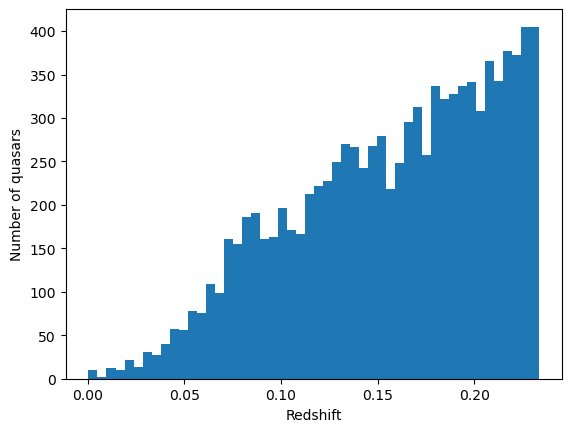

In [26]:
import numpy as np
import matplotlib.pyplot as plt

plt.hist(z, bins=50)

plt.xlabel("Redshift")
plt.ylabel("Number of quasars")

plt.show()

In [27]:
counts, bin_edges = np.histogram(z, bins=50)

bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

In [28]:
x = bin_centers
y = counts

# fit lineare y = m x + b
m, b = np.polyfit(x, y, 1)

print(m, b)

1778.442043728891 -8.089299530569987


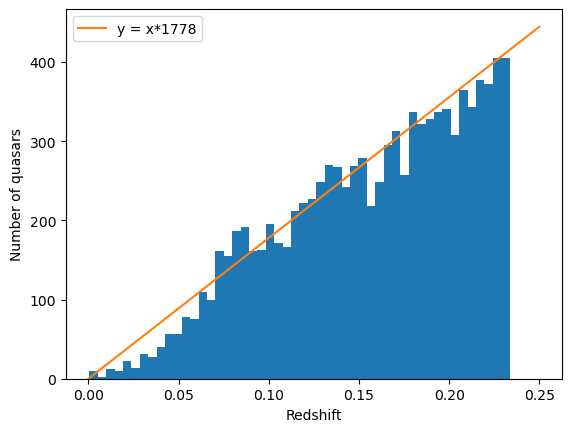

In [36]:
plt.hist(z, bins=50)

x = np.linspace(0, 0.25, 100)

plt.xlabel("Redshift")
plt.ylabel("Number of quasars")

plt.plot(x, x*1778, label="y = x*1778")

plt.legend()

plt.show()

### Rejection sampling

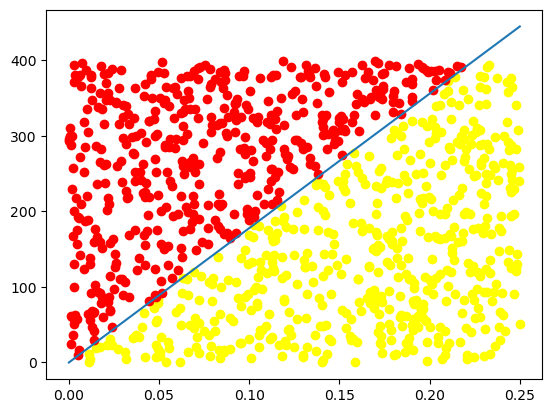

(array([ 4.,  1.,  3.,  1.,  2.,  3.,  3.,  7.,  5.,  2.,  6.,  4.,  9.,
         3.,  8.,  6.,  4.,  6.,  9., 13.,  8., 10., 13.,  7.,  8.,  8.,
         9., 16.,  7., 10., 10., 10.,  8., 25., 10., 17., 19., 18., 16.,
        18., 17., 19., 15., 19., 19., 24., 19., 15., 19., 16.]),
 array([0.01127049, 0.01604471, 0.02081893, 0.02559316, 0.03036738,
        0.0351416 , 0.03991583, 0.04469005, 0.04946427, 0.0542385 ,
        0.05901272, 0.06378694, 0.06856116, 0.07333539, 0.07810961,
        0.08288383, 0.08765806, 0.09243228, 0.0972065 , 0.10198073,
        0.10675495, 0.11152917, 0.1163034 , 0.12107762, 0.12585184,
        0.13062607, 0.13540029, 0.14017451, 0.14494873, 0.14972296,
        0.15449718, 0.1592714 , 0.16404563, 0.16881985, 0.17359407,
        0.1783683 , 0.18314252, 0.18791674, 0.19269097, 0.19746519,
        0.20223941, 0.20701364, 0.21178786, 0.21656208, 0.2213363 ,
        0.22611053, 0.23088475, 0.23565897, 0.2404332 , 0.24520742,
        0.24998164]),
 <BarContainer

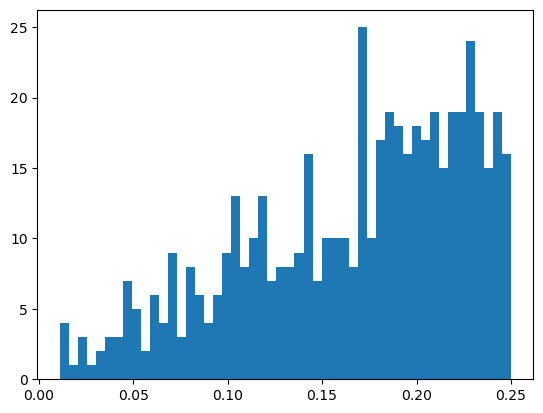

In [37]:
f = lambda x: x*1778

N = 1000

xg = np.linspace(0, 0.25, 100)

plt.plot(xg, f(xg))

ymax = 400
x = np.random.uniform(0, 0.25, N)
y = np.random.uniform(0, ymax, N)

plt.scatter(x[y<f(x)], y[y<f(x)], c="yellow")
plt.scatter(x[y>f(x)], y[y>f(x)], c="red")

plt.show()
goodpoints = x[y<f(x)]

plt.hist(goodpoints, bins = 50)

### Inverse transform sampling

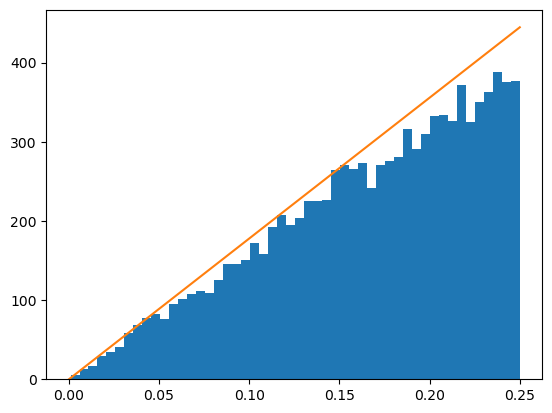

In [42]:
eps = np.random.uniform(0, 1, 10000)

x = np.sqrt(eps)/4

plt.hist(x, bins = 50)

xv = np.linspace(0, 0.25, 100)
plt.plot(xv, 1778*xv)